Optimize ```train.ipynb``` data enhancement strategy:
- expand the image rotation enhancement parameter range
- add horizontal/verical flip enhancement

Introduce differentiated evaluation indicators:
- set independent accuracy thresholds for training set/test set
- implement dynamic overfitting monitoring mechanism

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
import import_ipynb
import model
from model import LightGestureNet
from model import InvertedResidual

Train data:
X_train shape:  (11200, 96, 96)
y_train shape:  (11200,)
X_train shape:  (11200, 1, 96, 96)
LightGestureNet(
  (first): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (layers): Sequential(
    (0): InvertedResidual(
      (conv): Sequential(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=96, bias=False)
        (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU6(inplace=True)
        (6): Conv2d(96, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (7): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, 

In [4]:
class GestureDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = torch.FloatTensor(X).unsqueeze(1)
        self.y = torch.LongTensor(y)
        self.transform = transform
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label
        

train_transform = transforms.Compose([
    transforms.RandomRotation(90), # change to 90 degrees
    transforms.RandomAffine(0, scale=(0.8, 1.2)),
    transforms.RandomAffine(0, translate=(0.2, 0.2)),
    transforms.RandomHorizontalFlip(),  # add more 
    transforms.RandomVerticalFlip()  # add more
])

In [5]:
with open('../dataset/train.pkl', 'rb') as f:
    X_train, y_train = pickle.load(f)
with open('../dataset/test.pkl', 'rb') as f:
    X_val, y_val = pickle.load(f)

train_dataset = GestureDataset(X_train, y_train, transform=train_transform)
val_dataset = GestureDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("TrainDataset Length: ", len(train_dataset))
print("ValDataset Length: ", len(val_dataset))

TrainDataset Length:  11200
ValDataset Length:  2400


In [6]:
import torch.nn.init as init

def weight_init(m):
    if isinstance(m, nn.Conv2d):
        init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        init.constant_(m.weight, 1)
        init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        init.xavier_normal_(m.weight)
        if m.bias is not None:
            init.constant_(m.bias, 0)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = LightGestureNet().to(device)

num_epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.apply(weight_init)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

best_val_loss = float('inf')
patience = 5
patience_counter = 0

Device: cpu


In [9]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    epoch_train_loss = train_loss / len(train_loader)
    epoch_train_acc = 100. * train_correct / train_total

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()


    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100. * val_correct / val_total

    scheduler.step()

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f'\nEpoch {epoch+1}/{num_epochs}:')
    print(f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%')
    print(f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

    ACCURACY_TRAIN_THRESHOLD = 98.08 # change from 96.61 to 98.08
    ACCURACY_VAL_THRESHOLD = 92.10 # down from 93.73 to 92.10

    MAX_TRAIN_VAL_DIFF = 7.90 # new

    if epoch_train_acc >= ACCURACY_TRAIN_THRESHOLD and epoch_val_acc >= ACCURACY_VAL_THRESHOLD:
        if epoch_val_acc <= epoch_train_acc and (epoch_train_acc - epoch_val_acc) <= MAX_TRAIN_VAL_DIFF:
            print(f'\nAchieve the target accuracy! Epoch {epoch+1}')
            break
        else:
            print(f'epoch_train_acc smaller {epoch_val_acc}%!')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping: Validation loss did not improve for {patience} epochs')
            break

Epoch 1/50: 100%|██████████| 350/350 [03:44<00:00,  1.56it/s]



Epoch 1/50:
Train Loss: 1.4033, Train Acc: 49.26%
Val Loss: 0.9439, Val Acc: 65.83%


Epoch 2/50: 100%|██████████| 350/350 [03:31<00:00,  1.65it/s]



Epoch 2/50:
Train Loss: 0.6830, Train Acc: 79.00%
Val Loss: 0.8221, Val Acc: 66.83%


Epoch 3/50: 100%|██████████| 350/350 [03:40<00:00,  1.59it/s]


...


Epoch 13/50:
Train Loss: 0.0433, Train Acc: 98.73%
Val Loss: 0.0397, Val Acc: 99.04%
epoch_train_acc smaller 99.04166666666667%!


Epoch 14/50: 100%|██████████| 350/350 [03:50<00:00,  1.52it/s]



Epoch 14/50:
Train Loss: 0.0485, Train Acc: 98.74%
Val Loss: 0.0290, Val Acc: 99.25%
epoch_train_acc smaller 99.25%!


Epoch 15/50: 100%|██████████| 350/350 [03:56<00:00,  1.48it/s]



Epoch 15/50:
Train Loss: 0.0363, Train Acc: 98.98%
Val Loss: 0.0646, Val Acc: 97.17%

Achieve the target accuracy! Epoch 15


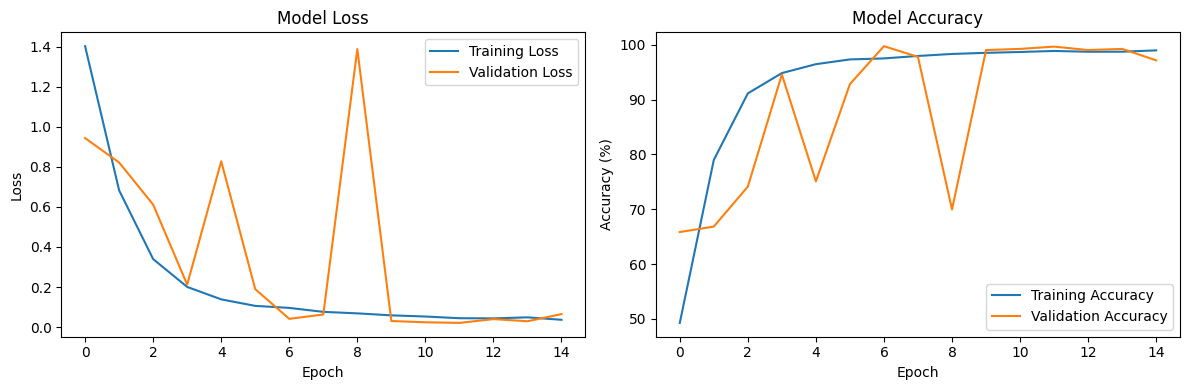

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
!pip install onnxscript

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 1.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 2.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
import torch
import onnx
import onnxruntime as ort
import tensorflow as tf
import numpy as np

device = torch.device("cpu")

model.load_state_dict(
    torch.load('best_model.pth', map_location=device, weights_only=False)
)
model.eval()
model.to(device)

# Pytorch
torch.save(model.state_dict(), 'gesture_model.pth')

# ONNX
dummy_input = torch.randn(1, 1, 96, 96).to(device)
onnx_model_path = 'gesture_model.onnx'
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)


# ONNX Runtime
try:
    ort_session = ort.InferenceSession(onnx_model_path)
    outputs = ort_session.run(
        None,
        {
            'input': dummy_input.numpy()
        }
    )
    print("ONNX model inference test succeeded, result:", outputs)
except Exception as e:
    print("Error during ONNX model inference: ", e)
    exit(1)


# Tensorflow SavedModel
class SimpleKerasModel(tf.keras.Model):
    def __init__(self):
        super(SimpleKerasModel, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(
            16,
            (3, 3),
            padding='same',
            activation='relu'
        )
        self.pool1 = tf.keras.layers.MaxPooling2D((2, 2))
        self.conv2 = tf.keras.layers.Conv2D(
            32,
            (3, 3),
            padding='same',
            activation='relu'
        )
        self.pool2 = tf.keras.layers.MaxPooling2D((2, 2))
        self.flatten = tf.keras.layers.Flatten()
        self.fc1 = tf.keras.layers.Dense(128, activation='relu')
        self.fc2 = tf.keras.layers.Dense(10)

    def call(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return self.fc2(x)
    
try:
    tf_model = SimpleKerasModel()
    tf_input = tf.convert_to_tensor(np.random.randn(1, 96, 96, 1), dtype=tf.float32)
    tf_model(tf_input)
    tf.saved_model.save(tf_model, 'tf_gesture_model')
    print(f"SavedModel: tf_gesture_model")
except Exception as e:
    print("Error during manual TensorFlow model creation: ", e)
    exit(1)


# TFLite
try:
    converter = tf.lite.TFLiteConverter.from_saved_model('tf_gesture_model')

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float32]

    tflite_model = converter.convert()

    with open('gesture_model.tflite', 'wb') as f:
        f.write(tflite_model)

    print("Model has been saved in the following formats:")
    print("- Pytorch (.pth)")
    print("- ONNX (.onnx)")
    print("- TFLite (.tflite)")
except Exception as e:
    print("Error during SavedModel to TFLite Conversion: ", e)
    exit(1)

/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/ipykernel_9021/3947428344.py:21: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `LightGestureNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LightGestureNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/Users/doanvankhoan/.pyenv/versions/3.10.13/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model inference test succeeded, result: [array([[ 11.083522, -20.997053, -36.8694  , -36.563255, -12.336569,
         84.61525 , -39.531612,  89.55096 ]], dtype=float32)]
INFO:tensorflow:Assets written to: tf_gesture_model/assets


INFO:tensorflow:Assets written to: tf_gesture_model/assets


SavedModel: tf_gesture_model
Model has been saved in the following formats:
- Pytorch (.pth)
- ONNX (.onnx)
- TFLite (.tflite)


W0000 00:00:1777280552.615050 18337305 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1777280552.615063 18337305 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1777280552.615701 18337305 reader.cc:83] Reading SavedModel from: tf_gesture_model
I0000 00:00:1777280552.615991 18337305 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1777280552.615995 18337305 reader.cc:147] Reading SavedModel debug info (if present) from: tf_gesture_model
I0000 00:00:1777280552.618239 18337305 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1777280552.618655 18337305 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1777280552.638499 18337305 loader.cc:220] Running initialization op on SavedModel bundle at path: tf_gesture_model
I0000 00:00:1777280552.644330 18337305 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 28631 microseconds.
I0000 00:00:1777280552.65889